In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
from sklearn.metrics import r2_score

In [33]:
df=sns.load_dataset("flights")
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [34]:
airP=df[["passengers"]].copy(deep=True)
print(airP)

     passengers
0           112
1           118
2           132
3           129
4           121
..          ...
139         606
140         508
141         461
142         390
143         432

[144 rows x 1 columns]


ADF p-value: 0.9919
The time series is not stationary (fail to reject H0).


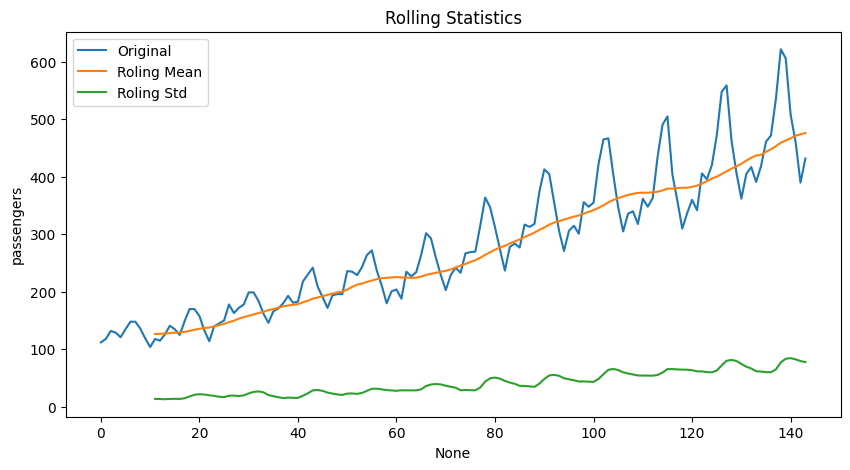

In [35]:
#Statinarity Check
def test_stationary(dataFrame,var,window=12):
    dataFrame["rollMean"]=dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd']=dataFrame[var].rolling(window=window).std()
    adf_result=adfuller(dataFrame[var])
    p_value=adf_result[1]
    print(f"ADF p-value: {p_value:.4f}")
    if p_value<0.05:
        print("Time time series is statinary (reject H0).")
    else:
        print("The time series is not stationary (fail to reject H0).")

    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.index, y=dataFrame[var],label='Original')
    sns.lineplot(x=dataFrame.index,y=dataFrame["rollMean"], label="Roling Mean")
    sns.lineplot(x=dataFrame.index,y=dataFrame["rollStd"], label="Roling Std")
    plt.title("Rolling Statistics")
    plt.legend()
    

#Test Statinarity
test_stationary(airP,'passengers')

ADF p-value: 0.9919
The time series is not stationary (fail to reject H0).
   passengers  rollMean  rollStd  shift  shiftDiff
0         112       NaN      NaN    NaN        NaN
1         118       NaN      NaN  112.0        6.0
2         132       NaN      NaN  118.0       14.0
3         129       NaN      NaN  132.0       -3.0
4         121       NaN      NaN  129.0       -8.0
ADF p-value: 0.0707
The time series is not stationary (fail to reject H0).
   passengers  rollMean  rollStd  shift  shiftDiff
0         112       NaN      NaN    NaN        NaN
1         118       NaN      NaN    NaN        NaN
2         132       NaN      NaN  112.0       20.0
3         129       NaN      NaN  118.0       11.0
4         121       NaN      NaN  132.0      -11.0
ADF p-value: 0.0397
Time time series is statinary (reject H0).


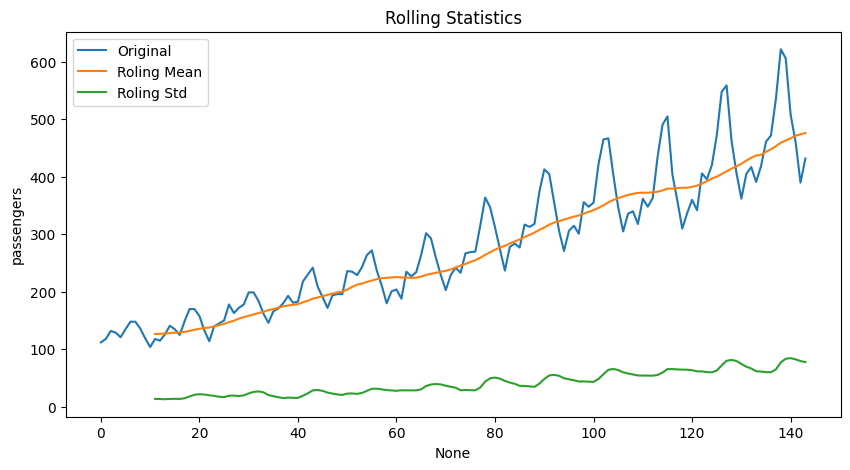

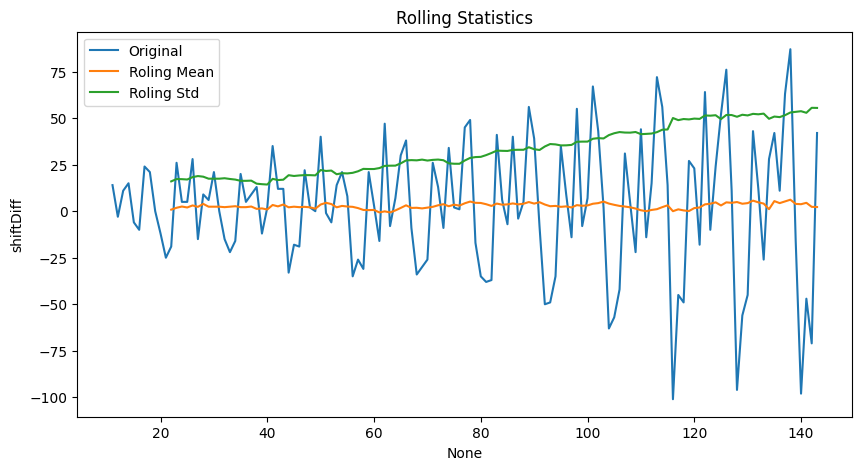

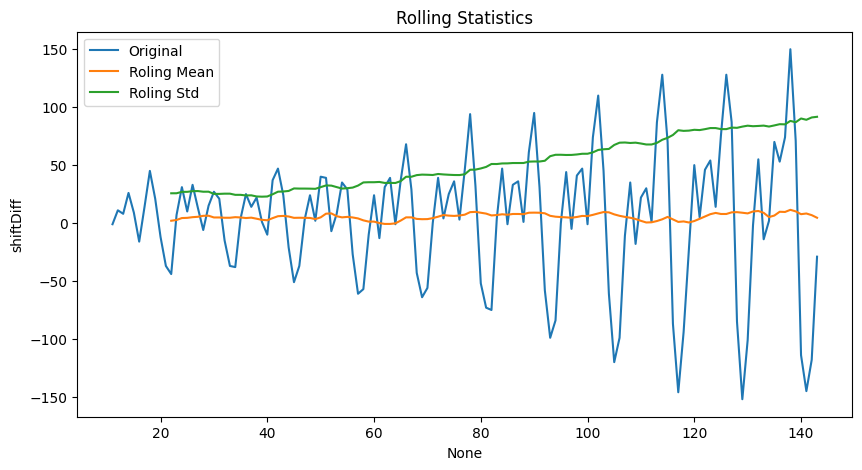

In [36]:
#test Stationary
test_stationary(airP,"passengers")
#data is not statoanry-let us try"dif"method
airP["shift"]=airP.passengers.shift(1)
airP["shiftDiff"]=airP["passengers"]-airP["shift"]
print(airP.head())
test_stationary(airP.dropna(),"shiftDiff")

airP["shift"]=airP.passengers.shift(2)
airP["shiftDiff"]=airP["passengers"]-airP["shift"]
print(airP.head())
test_stationary(airP.dropna(),"shiftDiff")

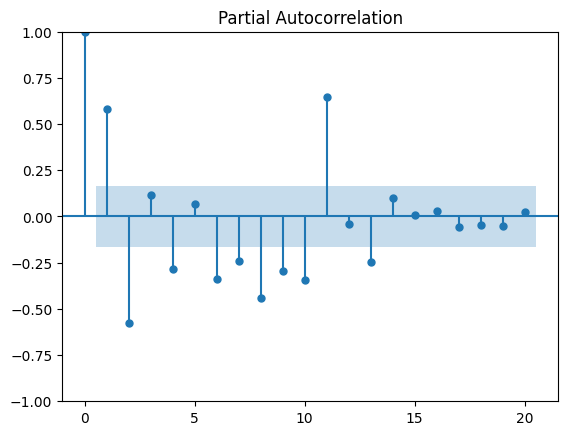

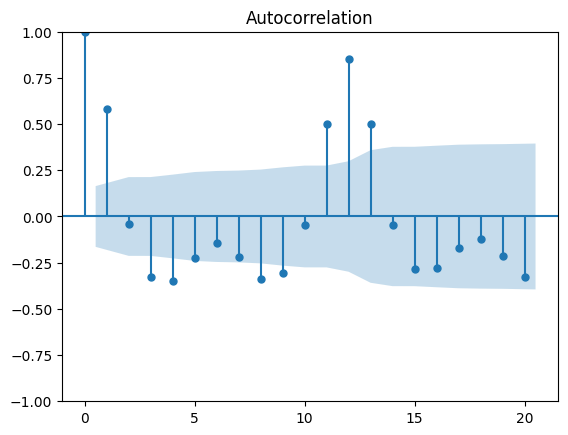

In [37]:
#ARIMA functiom:need 3 parameters:p,d,q
airP["secondDiff"]=airP["passengers"].diff(2)
airP["Diff12"]=airP["passengers"].diff(12)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#PACF plot(gives us "p" in ARIAMA)
plot_pacf(airP["secondDiff"].dropna(),lags=20)
plt.show()

#ACF plot(gives us "Q" in ARIAMA)
plot_acf(airP["secondDiff"].dropna(),lags=20)
plt.show()

In [38]:
#train-test split
train_size=int(len(airP)*0.7)#first 70%  in tarin
train=airP.iloc[:train_size]
test=airP.iloc[train_size:] # reamining 30% in tset

#ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_arima=ARIMA(train["passengers"],order=(1,2,1))#pdq
model_arima_fit=model_arima.fit()
arima_pred=model_arima_fit.predict(start=len(train),end=len(airP)-1)  #use test to predict

# Add ARIMA prediuction to dataframe
airP["arimaPred"]=np.nan   #first set all to null
airP.iloc[train_size:,airP.columns.get_loc("arimaPred")]=arima_pred.values # now add preditions only to test set
print(airP.tail()) # compare actual with predicted by ARIMA

     passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  Diff12  \
139         606  463.333333  83.630500  535.0       71.0        71.0    47.0   
140         508  467.083333  84.617276  622.0     -114.0      -114.0    45.0   
141         461  471.583333  82.541954  606.0     -145.0      -145.0    54.0   
142         390  473.916667  79.502382  508.0     -118.0      -118.0    28.0   
143         432  476.166667  77.737125  461.0      -29.0       -29.0    27.0   

      arimaPred  
139  439.708768  
140  442.074513  
141  444.440259  
142  446.806004  
143  449.171750  


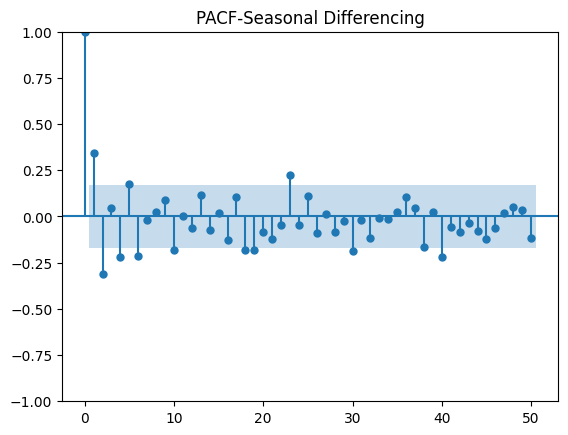

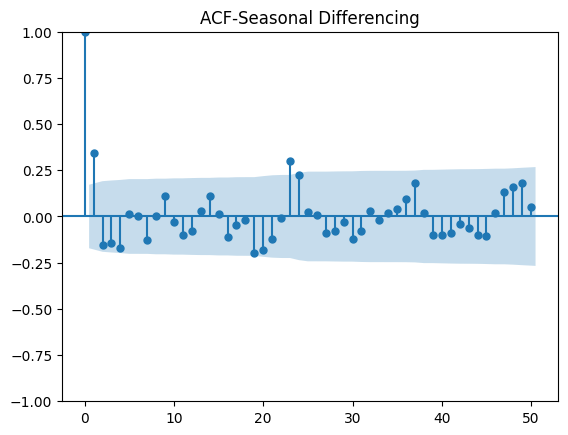

C:\Users\PGCP-AI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasoanl_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


     passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  Diff12  \
124         420  397.083333  60.008270  406.0       14.0        14.0    57.0   
125         472  400.166667  63.009138  396.0       76.0        76.0    37.0   
126         548  404.916667  71.987951  420.0      128.0       128.0    57.0   
127         559  409.416667  80.049369  472.0       87.0        87.0    54.0   
128         463  414.333333  81.485451  548.0      -85.0       -85.0    59.0   
129         407  418.333333  79.680422  559.0     -152.0      -152.0    48.0   
130         362  422.666667  74.498729  463.0     -101.0      -101.0    52.0   
131         405  428.333333  69.830097  407.0       -2.0        -2.0    68.0   
132         417  433.083333  66.624399  362.0       55.0        55.0    57.0   
133         391  437.166667  61.866180  405.0      -14.0       -14.0    49.0   
134         419  438.250000  61.382741  417.0        2.0         2.0    13.0   
135         461  443.666667  60.171472  

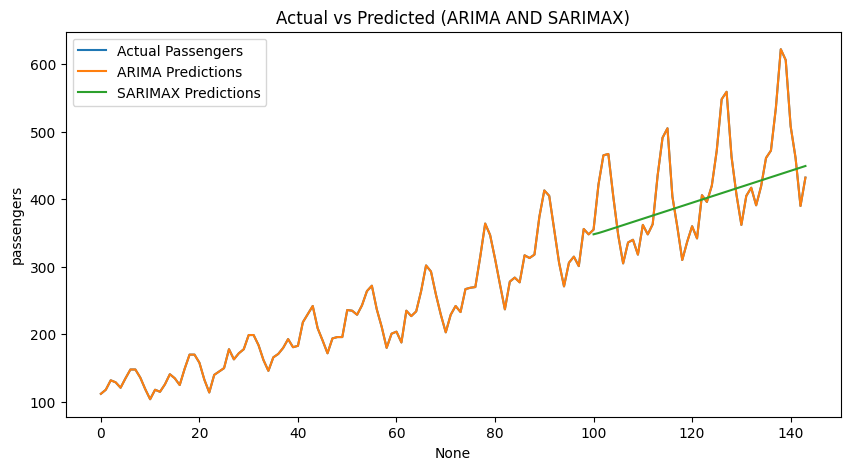

In [39]:
# SARIMAX Model
# To calculate P and Q for SARIMAX
airP["diff_combined"]= airP["passengers"].diff(2).diff(12)
plot_pacf(airP["diff_combined"].dropna(),lags=50)
plt.title("PACF-Seasonal Differencing")
plt.show()

plot_acf(airP["diff_combined"].dropna(),lags=50)
plt.title("ACF-Seasonal Differencing")
plt.show()

model_sarimax=SARIMAX(train["passengers"],order=(1,2,1),seasoanl_order=(1,2,1,12))#pdq
model_sarimax_fit=model_sarimax.fit()
sarimax_pred=model_sarimax_fit.predict(start=len(train),end=len(airP)-1)

#add SARIMAX prediction to dataframe
airP["sarimaxPred"]=np.nan   #first set all to null
airP.iloc[train_size:,airP.columns.get_loc("sarimaxPred")]=sarimax_pred.values # now add preditions only to test set
print(airP.tail(20))

#plot predictions
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index,y=airP["passengers"],label="Actual Passengers")
sns.lineplot(x=airP.index,y=airP["passengers"],label="ARIMA Predictions")
sns.lineplot(x=airP.index,y=airP["sarimaxPred"],label="SARIMAX Predictions")
plt.title("Actual vs Predicted (ARIMA AND SARIMAX)")
plt.legend()
plt.show()

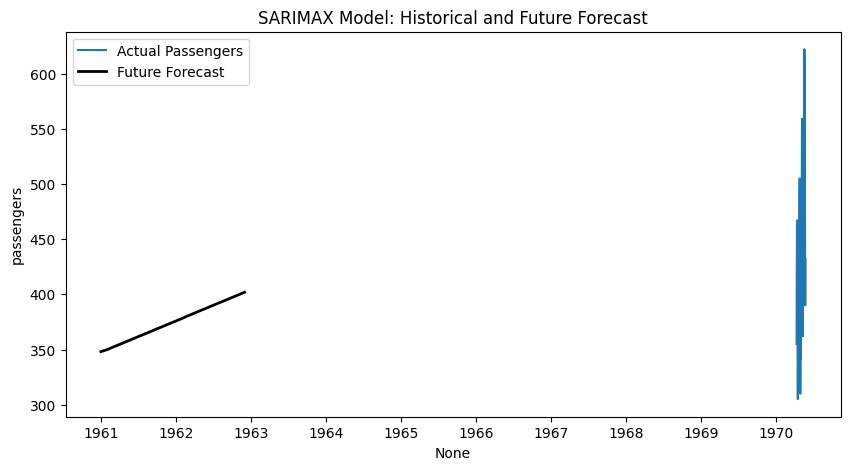

In [44]:
#Future Forecast using SARIMAX
future_dates=pd.DataFrame(pd.date_range(start='1961-01-01', end='1962-12-01', freq='MS'),columns=['Dates'])
future_dates.set_index('Dates',inplace=True)

future_forecast=model_sarimax_fit.predict(start=future_dates.index[0],end=future_dates.index[-1])
print(future_forecast)


#plot Future Forecast
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index,y=airP["passengers"],label="Actual Passengers")
sns.lineplot(x=airP.index,y=airP["sairmaxPred"],label="SARIMAX Predictions")
future_forecast.plot(color='black',label='Future Forecast')
plt.title("SARIMAX Model with future ")
plt.legend()
plt.show()

# # 1. Calculate the number of months to forecast
# # January 1961 to December 1962 is 24 months
# n_periods = 24 

# # 2. Get the forecast using the number of steps (avoids the KeyError)
# forecast_result = model_sarimax_fit.get_forecast(steps=n_periods)
# future_forecast_series = forecast_result.predicted_mean

# # 3. Create the date index manually so the plot looks correct
# future_dates = pd.date_range(start='1961-01-01', periods=n_periods, freq='MS')
# future_forecast_series.index = future_dates

# # 4. Plotting
# plt.figure(figsize=(10,5))
# # Historical data
# sns.lineplot(x=airP.index, y=airP["passengers"], label="Actual Passengers")
# sns.lineplot(x=airP.index, y=airP["sarimaxPred"], label="SARIMAX Predictions")

# # Future data (using the forecast series we just fixed)
# plt.plot(future_forecast_series.index, future_forecast_series.values, color='black', label='Future Forecast')

# plt.title("SARIMAX Model with future forecast")
# plt.legend()
# plt.show()

In [41]:
#Model Evaluation
airP=airP.dropna()
print(airP)
#ARIMA Metrics
column_name = 'arimaPred' # Change this if your print(airP.columns) showed something else
arima_mae=mean_absolute_error(airP['passengers'], airP[column_name])
arima_mse=mean_squared_error(airP['passengers'],airP[column_name])
arima_rmse=math.sqrt(arima_mse)
arima_r2=r2_score(airP['passengers'], airP[column_name])
print(f"ARIMA-> MAE:{arima_mae:.2f},RMSE:{arima_rmse:.2f}, R^2:{arima_r2:.2f}")

     passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  Diff12  \
100         355  342.083333  43.324271  356.0       -1.0        -1.0    37.0   
101         422  346.083333  48.451397  348.0       74.0        74.0    48.0   
102         465  350.416667  56.617470  355.0      110.0       110.0    52.0   
103         467  355.583333  64.351956  422.0       45.0        45.0    62.0   
104         404  359.666667  65.848771  465.0      -61.0       -61.0    49.0   
105         347  363.083333  63.844211  467.0     -120.0      -120.0    41.0   
106         305  365.916667  60.026446  404.0      -99.0       -99.0    34.0   
107         336  368.416667  57.890898  347.0      -11.0       -11.0    30.0   
108         340  370.500000  56.219537  305.0       35.0        35.0    25.0   
109         318  371.916667  54.496803  336.0      -18.0       -18.0    17.0   
110         362  372.416667  54.364859  340.0       22.0        22.0     6.0   
111         348  372.416667  54.364859  

In [42]:
#SARIMAX Metrics
sarimax_mae=mean_absolute_error(airP['passengers'],airP['sarimaxPred'])
sarimax_mse=mean_squared_error(airP['passengers'],airP['sarimaxPred'])
sarimax_rmse=math.sqrt(sarimax_mse)
sarimax_r2=r2_score(airP['passengers'],airP['sarimaxPred'])
print(f'SARIMAX->MAE:{sarimax_mae:.2f},RMSE:{sarimax_rmse:.2f}, R^2:{sarimax_r2:.2f}')

SARIMAX->MAE:53.92,RMSE:70.99, R^2:0.14
